In [1]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
from datasets import load_dataset
from StanceDetector import StanceDetector
import utils

random_seed=41


c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

In [7]:
# read records from json file
with open('./../data/external/records.json', 'r') as f:
    records = json.load(f) 


In [2]:
def politician_stance(summarizations, name):
    summary = summarizations[summarizations['speaker'] == name]['summary']
    if not summary.empty:
        return summary.iloc[0]
    else:
        return f"No summary found for {name}."

## Nuclear energy

In [3]:
# FOR DEBUGGING PURPOSES, TO RELOAD THE MODULE WITHOUT RESTARTING THE KERNEL

import importlib
import StanceDetector as sd_module

def reload_detector():
    importlib.reload(sd_module)
    return sd_module.StanceDetector

In [8]:
topic = "nuclear"

# DEBUG----------
StanceDetector = reload_detector()
# ------------------
uk=StanceDetector(df1, records, random_seed=random_seed)

c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014]) # years=[2011, 2012, 2013, 2014]

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

Filtering speeches for topic: nuclear
Number of speeches after filtering for topic 'nuclear' in years [2011, 2012, 2013, 2014]: 597
Classifying filtered speeches for topic: nuclear
"Number of opinionated speeches for nuclear: 43
Summarization completed for topic: nuclear


In [10]:
summarizations

,summary,party,speaker
0,The politician opposes the development of nucl...,Con,David Cameron
1,The politician believes nuclear energy should ...,Lab,Paul Flynn
2,The politician opposes the use of nuclear ener...,Con,Tony Baldry
3,The politician believes nuclear energy should ...,LibDem,Christopher Huhne
4,The politician opposes the development of new ...,LibDem,Martin Horwood
5,The politician opposes nuclear energy due to c...,GPEW,Caroline Lucas
6,The politician expresses concerns regarding th...,Con,Mike Weatherley
7,The politician opposes measures that could res...,Lab,Alan Whitehead
8,The politician opposes the use of nuclear ener...,Lab,Jeremy Corbyn
9,The politician opposes the expansion of nuclea...,Con,Charles Hendry


Note: Per questioni di mantenimento probabilmente sarebbe meglio salvare le summarization su file esterno e non all'interno della variabile. Altrimenti ogni volta dobbiamo runnare tutto da capo.

In [11]:
# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [9]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)
# -----------------

In [10]:
anchors=uk.generate_anchors("nuclear")

Generating stance anchors for topic: nuclear


In [11]:
anchors

[{'topic': 'The safety of nuclear energy deployment is a contested issue.',
  'pro': 'Nuclear energy should not be pursued due to significant cost overruns, safety concerns highlighted by the Fukushima disaster, and declining public confidence.',
  'con': 'The politician opposes the development of nuclear energy due to safety concerns and the lack of relevant infrastructure in the UK.'},
 {'topic': 'The financial implications of nuclear energy, specifically decommissioning and waste disposal, are a contested issue.',
  'pro': 'The politician opposes the use of nuclear energy due to concerns about the significant and unaddressed costs of decommissioning and nuclear waste disposal.',
  'con': 'The politician expresses concerns regarding the long-term financial viability and waste management challenges associated with nuclear energy.'},
 {'topic': 'The role of government funding and prioritization in relation to nuclear energy is a contested issue.',
  'pro': 'The politician believes nucl

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.94s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


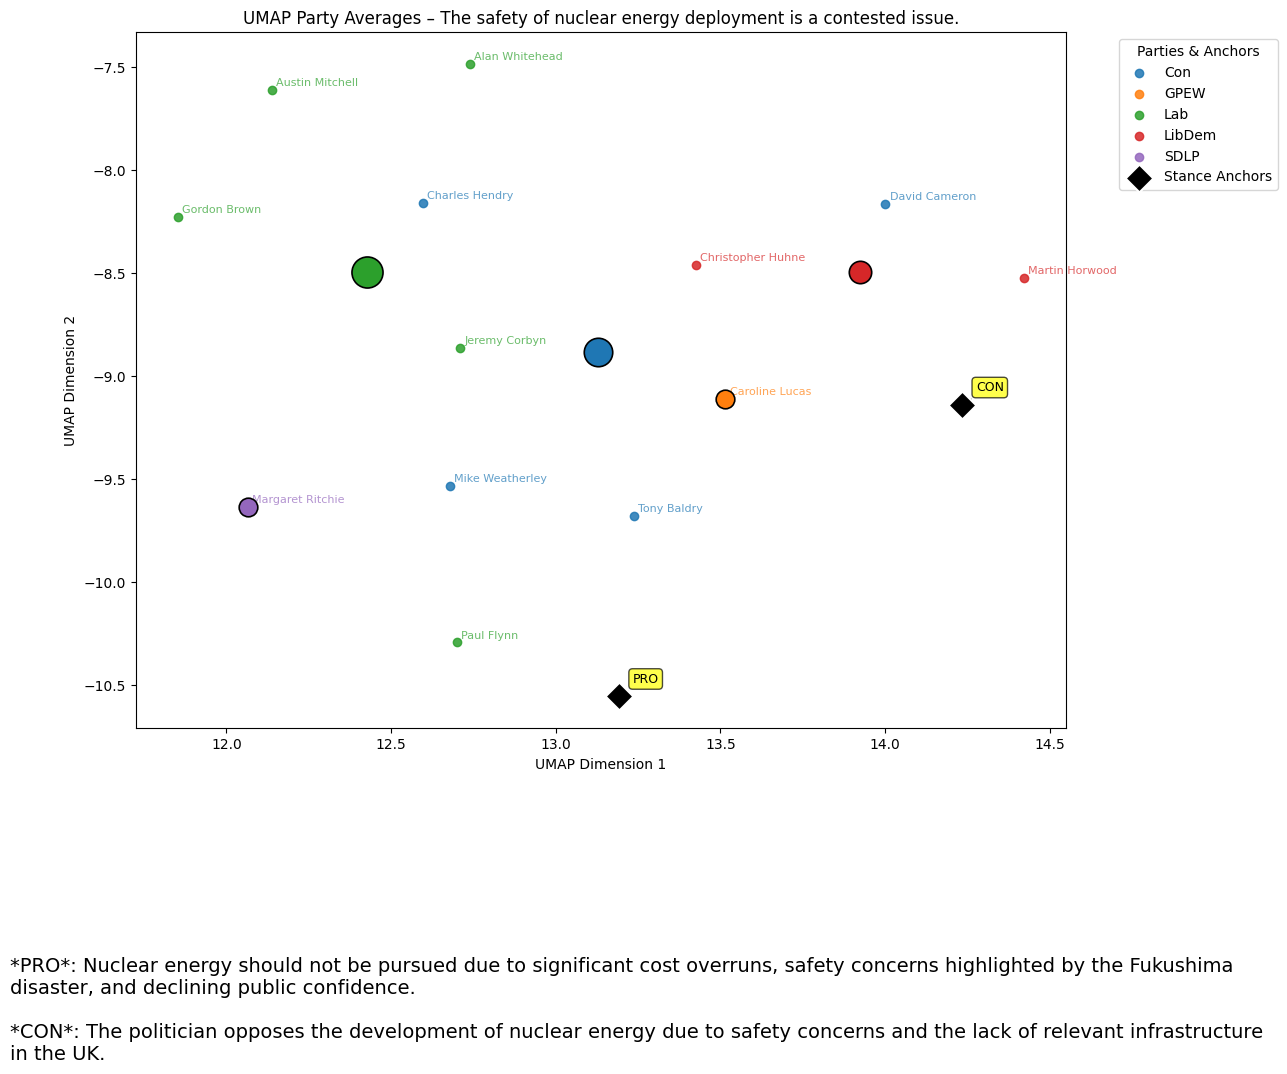

In [12]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[0])
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [13]:
politician_stance(summarizations=summarizations, name="Paul Flynn")

'The politician believes nuclear energy should not be pursued due to significant cost overruns, safety concerns highlighted by the Fukushima disaster, and declining public confidence, particularly given other countries’ abandonment of nuclear plans.'

In [31]:
politician_stance(summarizations=summarizations, name="Christopher Huhne")

'The politician believes nuclear energy should be part of the UK’s energy mix, but opposes government funding and recognises the need to maintain reliable power generation.'

In [32]:
politician_stance(summarizations=summarizations, name="Martin Horwood")

'The politician opposes the development of new nuclear power stations due to concerns about safety, cost, waste disposal, and lack of international standards.'

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.62s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


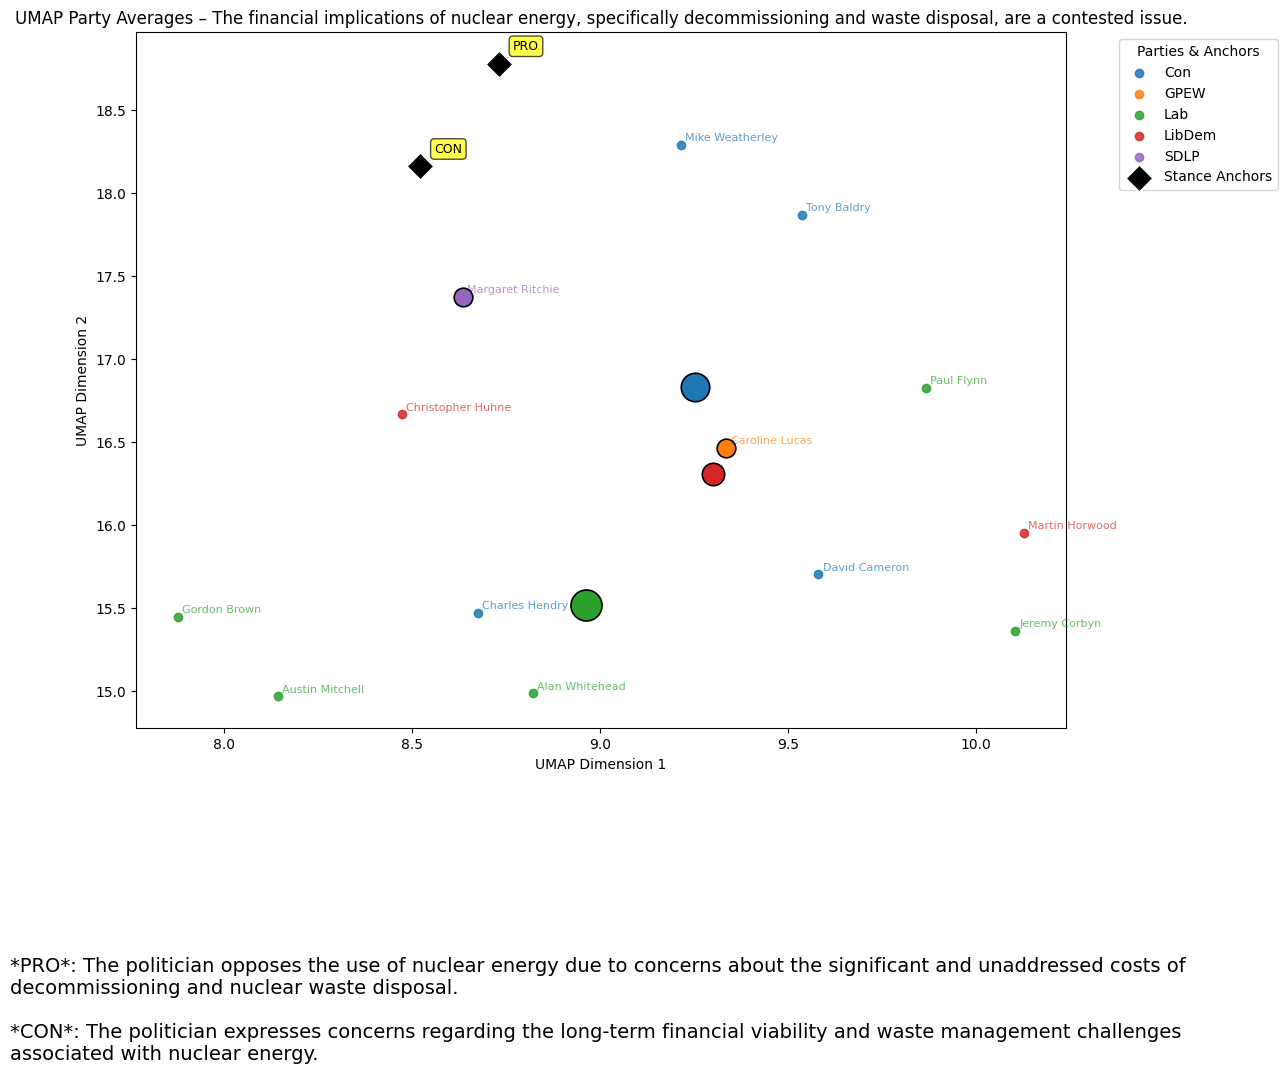

In [14]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[1])
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [55]:
politician_stance(summarizations=summarizations, name="Christopher Huhne")


'The politician believes nuclear energy should be part of the UK’s energy mix, but opposes government funding and recognises the need to maintain reliable power generation.'

## Gaza

In [15]:
topic='Gaza'


In [ ]:

filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [16]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)

In [17]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: Gaza


In [18]:
anchors

[{'topic': 'The need for dismantling Hamas in Gaza.',
  'pro': 'Hamas’s rejection of Israel, use of violence, and support from Iran necessitate its dismantling to ensure Israel’s security and prevent further conflict.',
  'con': 'Dismantling Hamas would leave a power vacuum in Gaza, potentially leading to greater instability and further complicating any future peace process.'},
 {'topic': 'The question of Palestinian statehood.',
  'pro': 'Palestinian statehood, achieved through negotiations and adherence to international law, is essential for resolving the conflict and providing Palestinians with self-determination.',
  'con': 'Granting Palestinian statehood to Hamas-controlled territory would be irresponsible due to Hamas’s rejection of Israel and commitment to violence.'},
 {'topic': 'The imperative of a ceasefire.',
  'pro': 'An immediate ceasefire, based on mutual concessions, is crucial to halt the ongoing violence, facilitate humanitarian aid, and create space for renewed negoti

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:07<00:00,  3.84s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


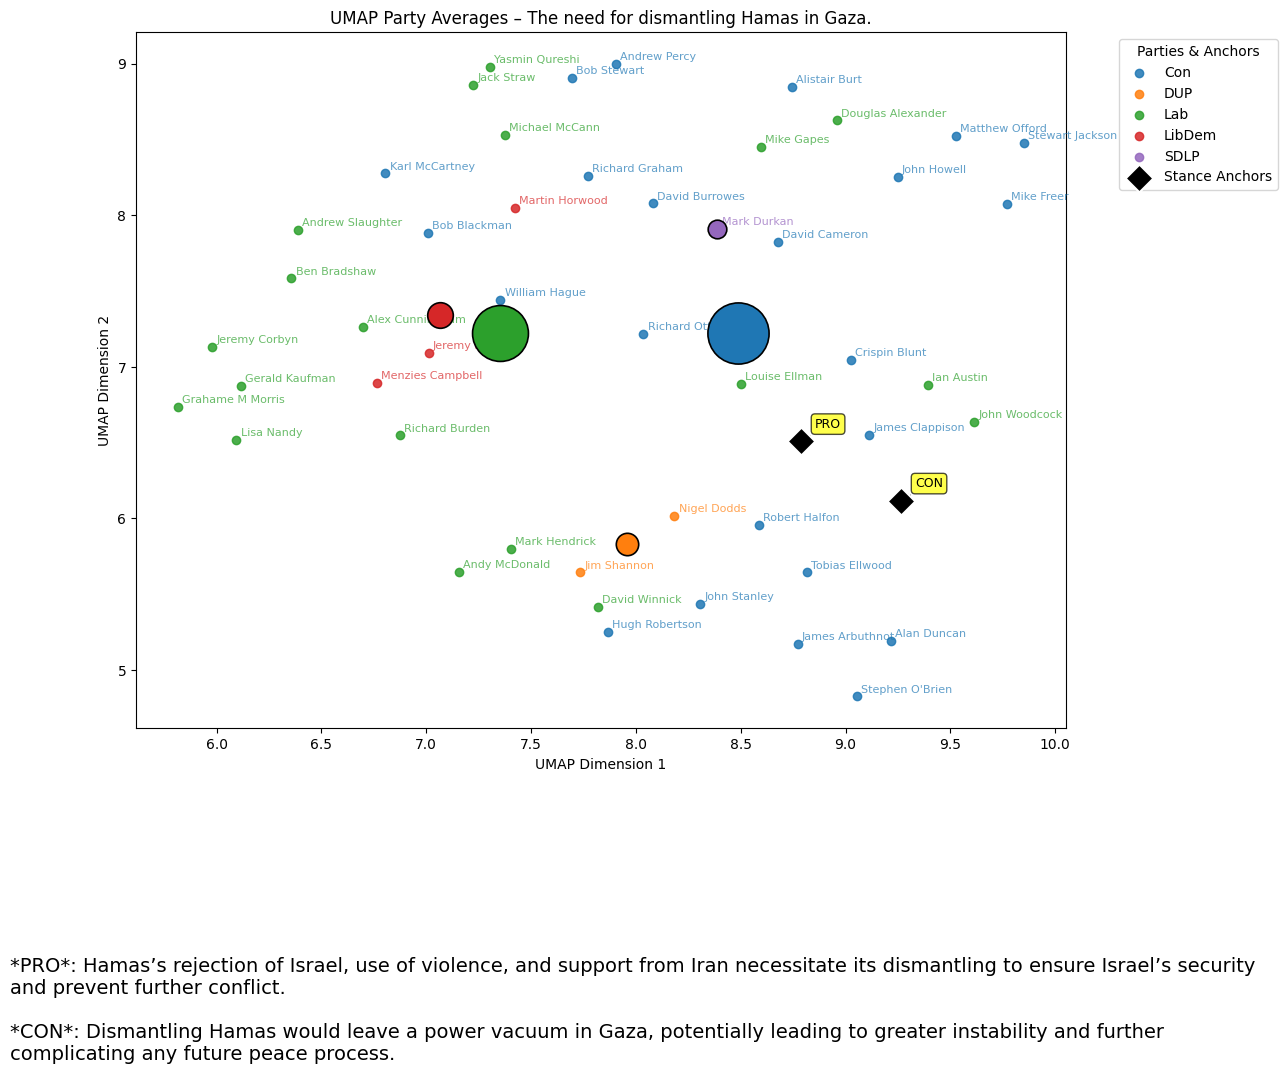

In [19]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:05<00:00,  2.85s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


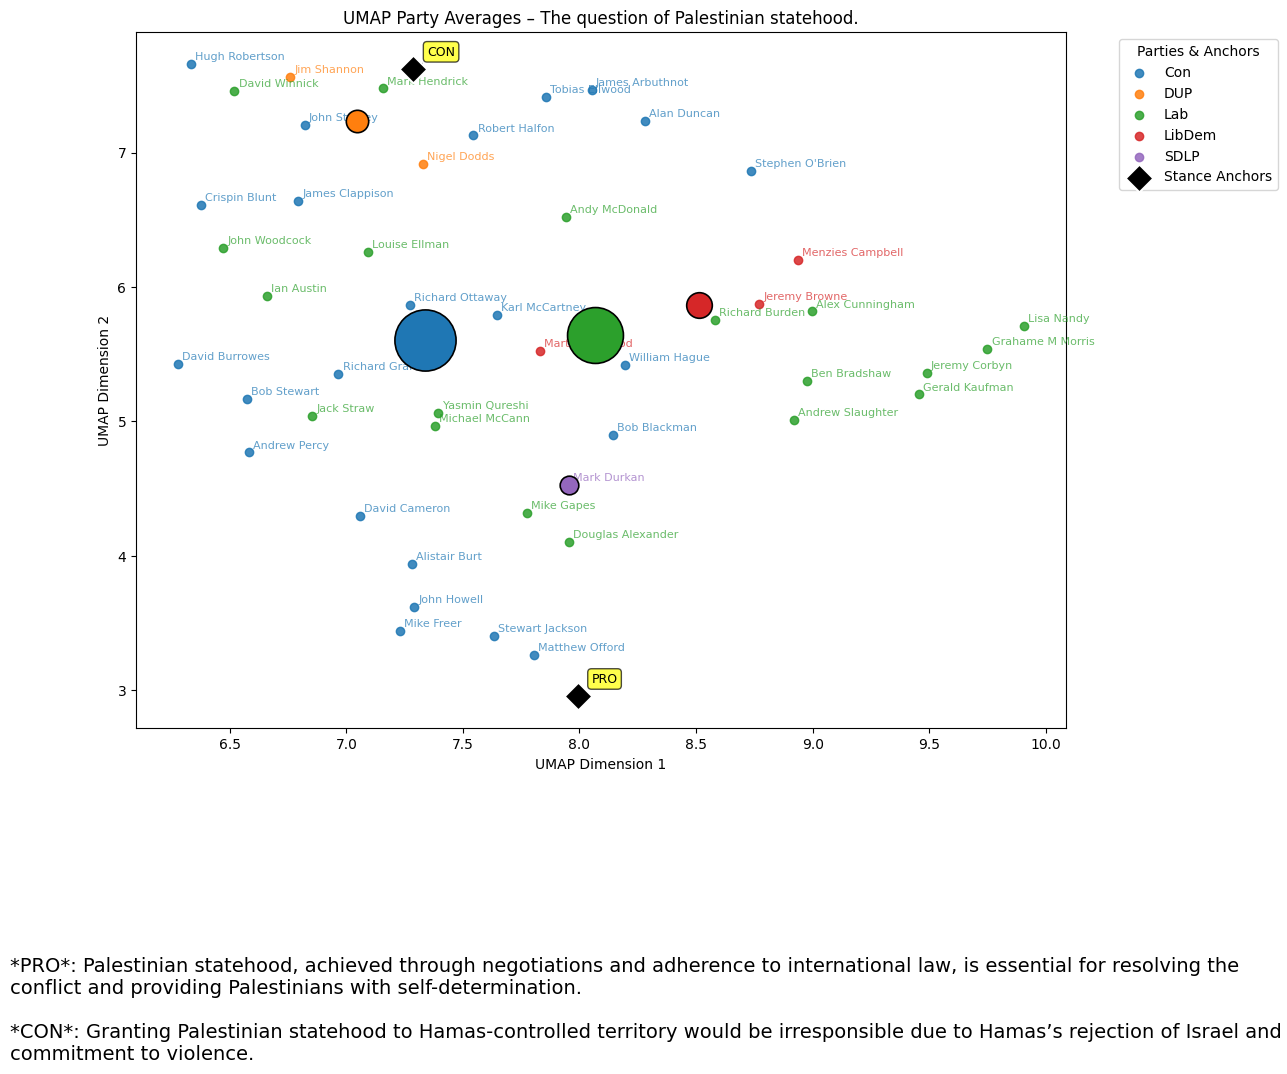

In [20]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

In [26]:
politician_stance(summarizations=summarizations, name="David Winnick")

'The politician opposes any agreement or engagement with Hamas due to its fundamentally different beliefs.'

In [ ]:
politician_stance(summarizations=summarizations, name="Jim Shannon")

'The politician opposes Palestinian statehood and enhanced recognition due to concerns about Hamas’s continued violence.'

In [24]:
politician_stance(summarizations=summarizations, name="Mike Freer")

'The politician believes that a lasting peace in the region is contingent upon Hamas accepting recognition of Israel and abiding by international agreements.'

In [22]:
politician_stance(summarizations=summarizations, name="Matthew Offord")

'The Minister believes a lasting resolution requires direct negotiations between Israel and the Palestinians addressing core issues like borders, security, and mutual recognition before any international declarations can be considered.'

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.01s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


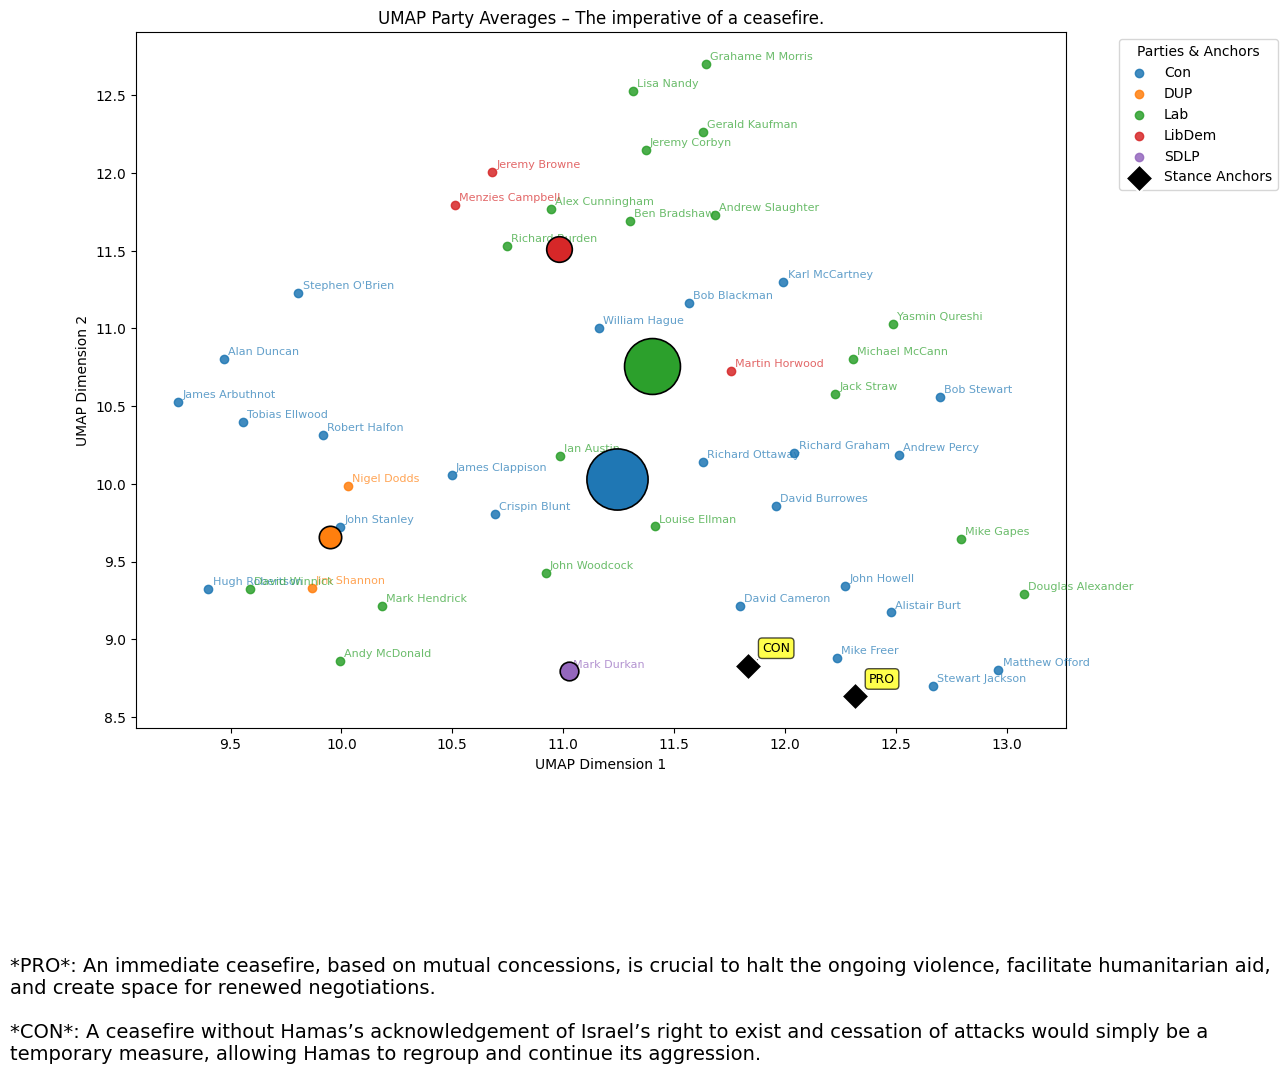

In [27]:
embeddings = uk.compute_umap_embeddings(topic, anchors[2])
uk.plot_umap_party_averages(embeddings, topic)

In [28]:
politician_stance(summarizations=summarizations, name="John Woodcock")

'The Foreign Secretary believes that Hamas’s commitment to destroying Israel prevents it from participating in any legitimate peace process.'

In [25]:
politician_stance(summarizations=summarizations, name="Tobias Ellwood")

'The politician advocates for a decisive change away from Hamas, expressing concern about the potential for a more extreme group to take its place.'

## Climate change

In [29]:
topic='climate change'

In [30]:
filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2011, 2012, 2013, 2014]: 1265
Classifying filtered speeches for topic: climate change
"Number of opinionated speeches for climate change: 125
Summarization completed for topic: climate change


In [ ]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)   

In [31]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: climate change


Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.18s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


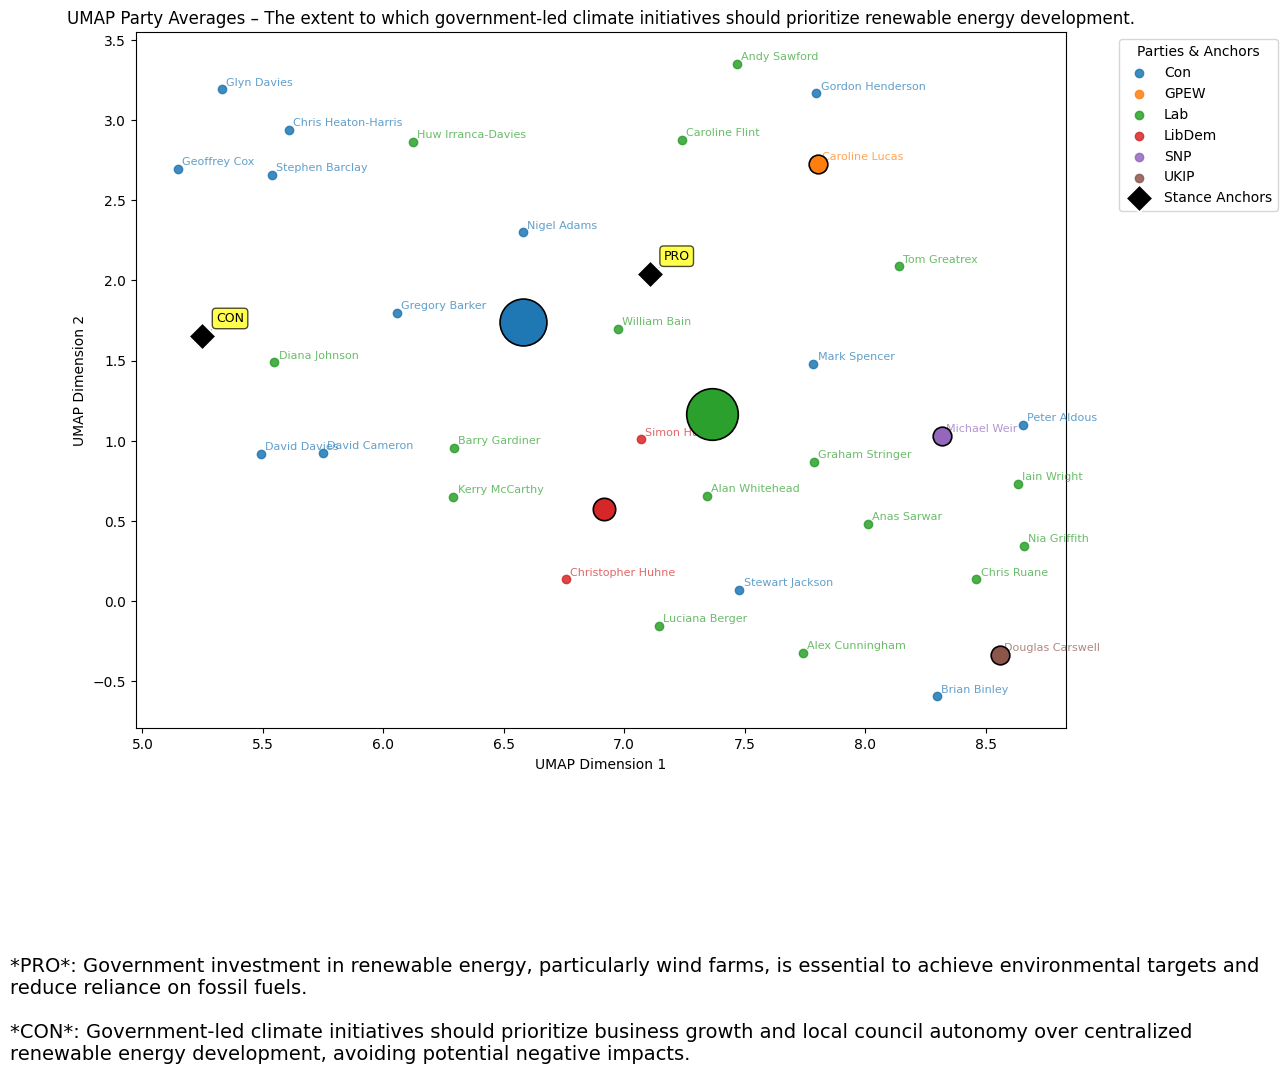

In [32]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:03<00:00,  1.80s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


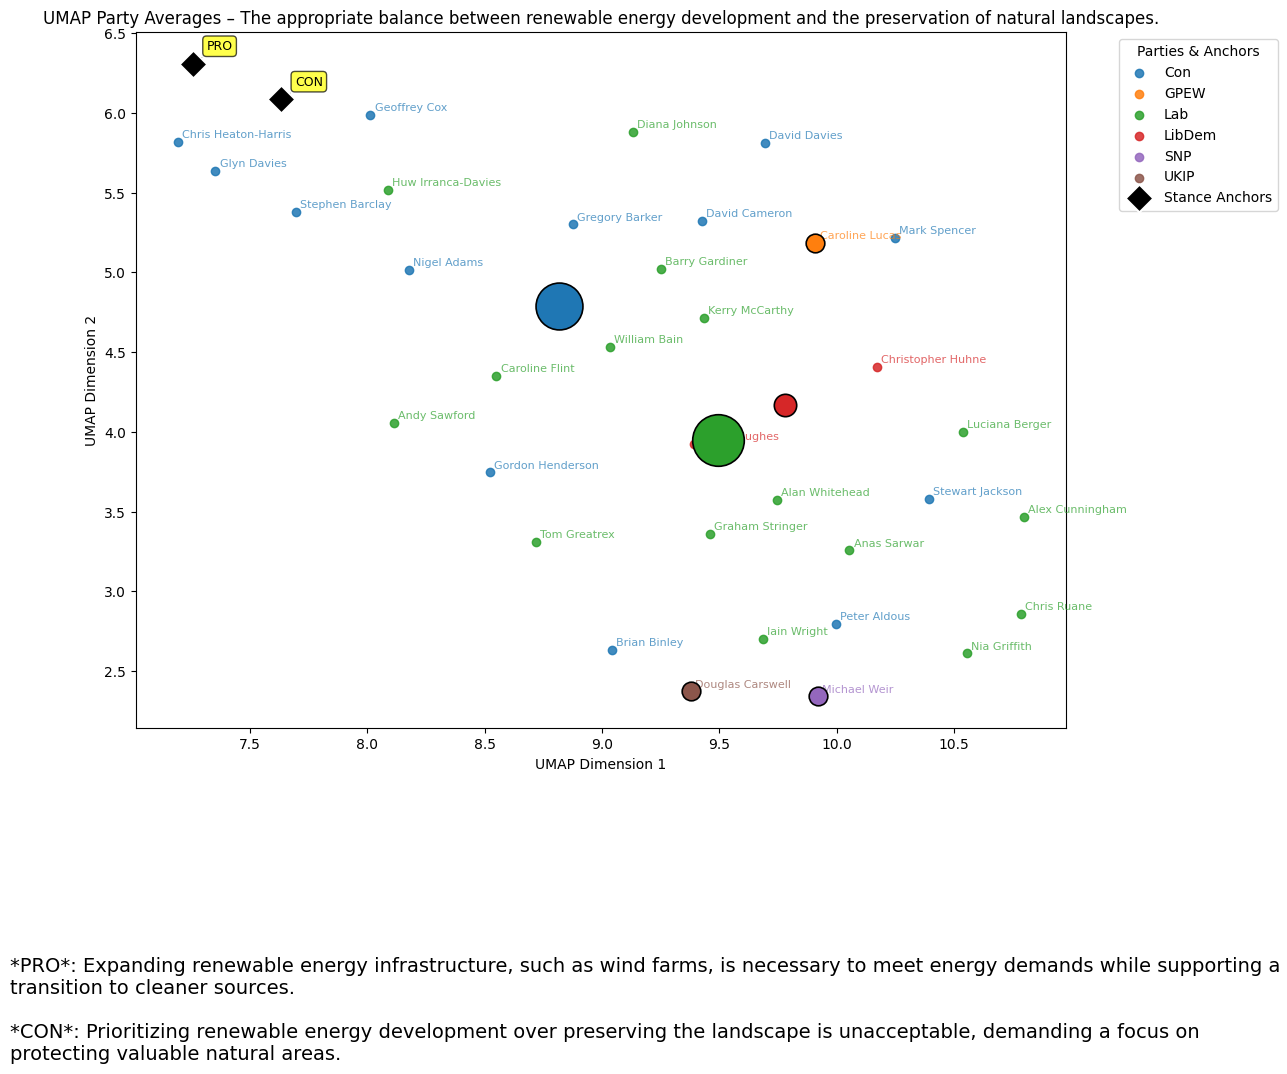

In [33]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:03<00:00,  1.92s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


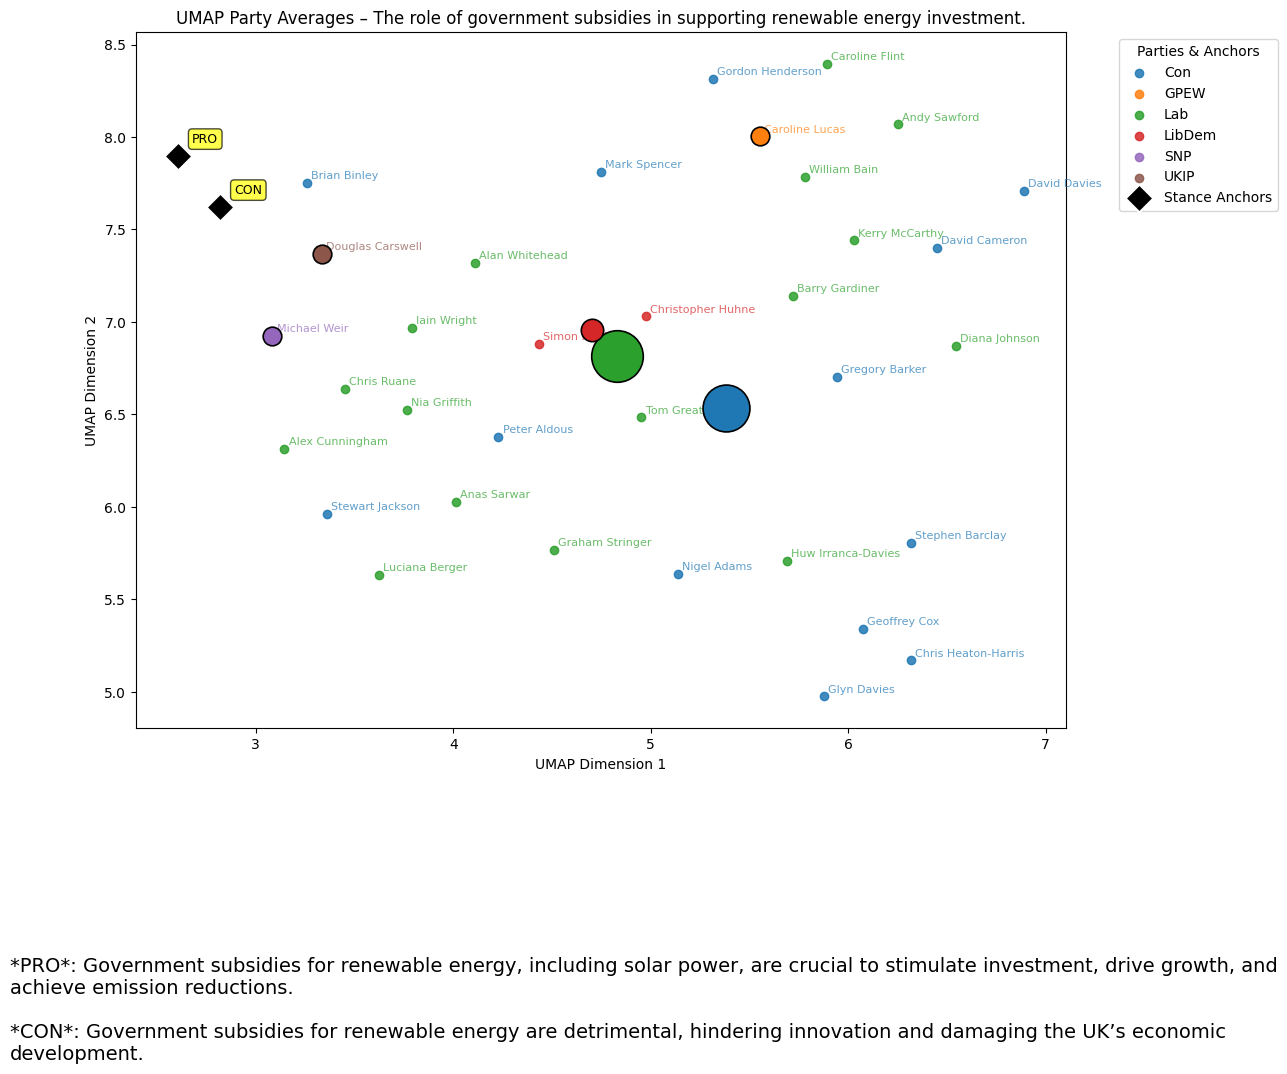

In [34]:
embeddings = uk.compute_umap_embeddings(topic, anchors[2])
uk.plot_umap_party_averages(embeddings, topic)

In [ ]:
# compute axis vector for the anchors
